# QuDiPy Conditional Sequence Playback

Plays multiple pulse sequences simultaneously based on pulses generated with QuDiPy. Starts with the GHZ state prep, then into a readout sequence, followed by a simulated trigger and a conditional X gate. For this notebook, the outputs are being viewed on the LeCroy scope. The QRM outputs O1 and O2 are connected to inputs I1 and I2 respectively. QCM outputs O1, O2, O3 and O4 are connected to the scope. The scope should be set to 1MOhm input impedance.

Authors: Noah Stieler, Luke Dyer

In [1]:
import json

import numpy as np
import matplotlib.pyplot as plt

from qblox_instruments import Cluster
from qblox_instruments.types import InstrumentType

In [2]:
#Scan for clusters
!qblox-pnp list

Devices:
 - 192.168.137.2: cluster_mm 0.6.2 with name "cluster-mm" and serial number 00015_2251_003


#### Configure and connect to Qblox modules

In [3]:
cluster = Cluster("cluster_mm", "192.168.137.2")
moduleQRM = None
moduleQCM = None

modules = [mod for mod in cluster.modules if mod.present()]
for mod in modules:
	print(str(mod) + " type=" + str(mod.module_type) + " is_rf_type=" + str(mod.is_rf_type))

cluster.reset()
cluster.get_system_state()

moduleQRM = modules[1]
moduleQCM = modules[0]

moduleQCM.disconnect_outputs()
moduleQCM.sequencer0.connect_sequencer("out0_1")
moduleQCM.sequencer1.connect_sequencer("out2_3")
moduleQCM.sequencer0.sync_en(True)						#Enable wait_sync Q1ASM instruction
moduleQCM.sequencer1.sync_en(True)

#Configure QRM for conditional playback
integrationLength = 120
moduleQRM.sequencer0.integration_length_acq(integrationLength)
moduleQRM.sequencer0.nco_freq(50e6)	#This sets the modulation frequency
moduleQRM.sequencer0.mod_en_awg(True)
moduleQRM.sequencer0.demod_en_acq(True)
moduleQRM.disconnect_inputs()
moduleQRM.disconnect_outputs()
moduleQRM.sequencer0.connect_sequencer("io0_1")

<QcmQrm: cluster_mm_module2 of Cluster: cluster_mm> type=QCM is_rf_type=False
<QcmQrm: cluster_mm_module4 of Cluster: cluster_mm> type=QRM is_rf_type=False
<QcmQrm: cluster_mm_module6 of Cluster: cluster_mm> type=QCM is_rf_type=True


#### Play 4 Waveforms

In [4]:
def playFourWaveforms(filename: str, waveformNames: list[str], plotTitle: str) -> None:

	# Load in pulse data
	pulseData = None
	with open(filename, encoding="utf-8") as file:
		pulseData = json.load(file)
		file.close()

	V_1 = pulseData[waveformNames[0]]
	V_2 = pulseData[waveformNames[1]]
	V_3 = pulseData[waveformNames[2]]
	W_1 = pulseData[waveformNames[3]]

	# Plot the pulses
	fig, ax = plt.subplots(1, 1, figsize=(6.5, 5))
	ax.plot(V_1, label=waveformNames[0])
	ax.plot(V_2, label=waveformNames[1])
	ax.plot(V_3, label=waveformNames[2])
	ax.plot(W_1, label=waveformNames[3])
	ax.set_xlabel("Time [s]")
	ax.set_ylabel("Voltage [V]")
	ax.legend()
	ax.set_title(plotTitle)
	plt.show()
	
	#Length are in nanoseconds
	waveformLength = len(V_1)

	# Play waveform 0 on first output and waveform 1 on second output and wait for the waveform length
	sequenceProgram = f"""
		wait_sync	4
		play		0,1,{waveformLength}	
		stop
	"""

	# Set the waveforms to play on the QRM and QCM
	waveformsSequencer0 = {
		"V_1" : {"data": (np.array(V_1) / 5).tolist(), "index": 0},
		"W_1" : {"data": (np.array(W_1) / 5).tolist(), "index": 1},
	}

	# Waveforms on the QCM are divided by 5 because the QCM module has a range from +/2.5V on a 50Ohm load but this goes to +/- 5.0V on a 1MOhm load
	# The waveforms are a percentage of this range.
	waveformsSequencer1 = {
		"V_2" : {"data": (np.array(V_2) / 5).tolist(), "index": 0},
		"V_3" : {"data": (np.array(V_3) / 5).tolist(), "index": 1},
	}

	# Upload the JSON files
	moduleQCM.sequencer0.sequence({"waveforms": waveformsSequencer0,"weights": {},"acquisitions": {},"program": sequenceProgram})
	moduleQCM.sequencer1.sequence({"waveforms": waveformsSequencer1,"weights": {},"acquisitions": {},"program": sequenceProgram})

	#Change the number of iterations if you want to average the waveforms
	for i in range(1):

		moduleQCM.arm_sequencer(0)
		moduleQCM.arm_sequencer(1)

		moduleQCM.start_sequencer()

		print(moduleQCM.get_sequencer_state(0))
		print(moduleQCM.get_sequencer_state(1))

#### Play GHZ preparation and ancilla readout sequences

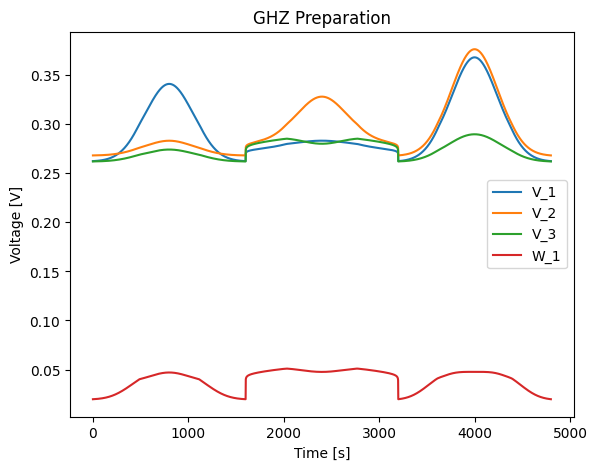

Status: STOPPED, Flags: NONE
Status: STOPPED, Flags: NONE


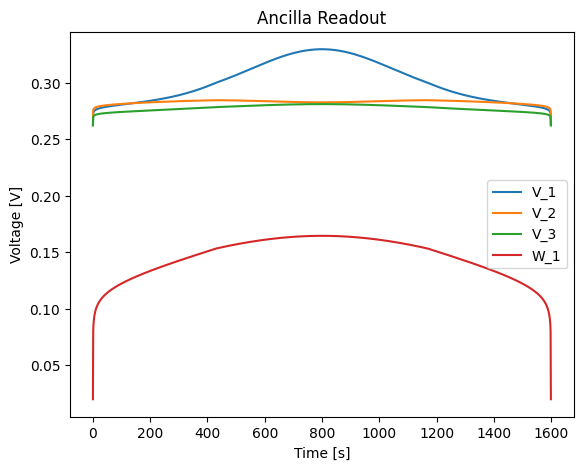

Status: STOPPED, Flags: NONE
Status: STOPPED, Flags: NONE


In [5]:
playFourWaveforms("GHZ_prep_example_nodeA.json", ["V_1", "V_2", "V_3", "W_1"], "GHZ Preparation")
playFourWaveforms("Ancilla_readout_example_nodeA.json", ["V_1", "V_2", "V_3", "W_1"], "Ancilla Readout")

#### Configure and run QRM for conditional playback

1.4477535803730217


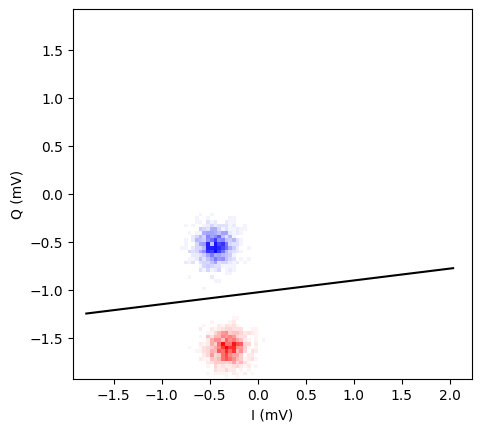

In [6]:
tof = 144	#Time of flight in nanoseconds, see timeOfFlightComp.ipynb to detemine it.

waveformLengthQRM = 120
t = np.arange(-80, 81, 1)
sigma = 20
waveforms = {
	"zero": {"data": [0.0] * 1024, "index": 0},
	"one": {"data": [1.0] * 1024, "index": 1},
	"state0_I": {"data": [0.001] * waveformLengthQRM, "index": 2},
	"state0_Q": {"data": [0.001] * waveformLengthQRM, "index": 3},
	"state1_I": {"data": [0.001] * waveformLengthQRM, "index": 4},
	"state1_Q": {"data": [0.003] * waveformLengthQRM, "index": 5},
	"gauss": {"data": list(np.exp(-(0.5 * t**2 / sigma**2))), "index": 6},
	"empty": {"data": list(0.0 * t), "index": 7}
}
acquisitions = {
	"state0": {"index": 0, "num_bins": 1024}, #Each bin stores an integration result
	"state1": {"index": 1, "num_bins": 1024}
}

#Store the integrated result of each modulated signal, and repeat 1024 times
sequenceProgram = f"""
	move			0,R0

	start:
		play		2,3,{tof}
		acquire		0,R0,{waveformLengthQRM}
		play		4,5,{tof}
		acquire	1,R0,{waveformLengthQRM}
		add			R0,1,R0
		wait		4000
		jlt			R0,1024,@start

	upd_param	4
	stop

"""

sequence = {
	"waveforms": waveforms,
	"weights": {},
	"acquisitions": acquisitions,
	"program": sequenceProgram
}
moduleQRM.sequencer0.sequence(sequence)

moduleQRM.arm_sequencer(0)
moduleQRM.start_sequencer()

moduleQRM.get_acquisition_state(0, 1)
moduleQRM.store_scope_acquisition(0, "state0")
moduleQRM.store_scope_acquisition(0, "state1")
data = moduleQRM.get_acquisitions(0)

#We don't take the actual integration values (ie state0/integration length) because the only relevant
#information here is the difference between the two states, not the actual data points themselves.
state0 = np.array(data["state0"]["acquisition"]["bins"]["integration"]["path0"]) + 1j *np.array(
	data["state0"]["acquisition"]["bins"]["integration"]["path1"])
state1 = np.array(data["state1"]["acquisition"]["bins"]["integration"]["path0"]) + 1j *np.array(
	data["state1"]["acquisition"]["bins"]["integration"]["path1"])

#Rotation and threshold values define a line which delineates between state0 and state1
#The rotation value is the angle measured from the vertical axis, the threshold is the length of the
#vector that is normal to the line, starting at the origin.

#More information: https://qblox-qblox-instruments.readthedocs-hosted.com/en/main/cluster/q1_sequence_processor.html

#Modulo operation is to ensure final angle is on the interval [0, 2pi].
rotation = np.mod(-np.angle(np.mean(state1) - np.mean(state0)), 2 * np.pi)
print(rotation)

#Once vetical line has been rotated, it needs to be offset. We rotate the mean
#vector of the two points to get the threshold. To understand this, instead of thinking of
#rotating the vector in the CCW direction, instead rotate the IQ axis in the CW direction. Then 
#the distance between the mean and the rotated line is the real part of the mean.
averageVec = (np.mean(state1) + np.mean(state0))/2
threshold = (np.exp(1j*rotation) * averageVec).real

#Plotting the histogram
scaling = 1000 / integrationLength
maxr = max(np.max(np.abs(state0)), np.max(np.abs(state1)))
hist0, xedges, yedges = np.histogram2d(
    state0.real, state0.imag, range=((-maxr, maxr), (-maxr, maxr)), bins=100
)
hist1, xedges, yedges = np.histogram2d(
    state1.real, state1.imag, range=((-maxr, maxr), (-maxr, maxr)), bins=100
)

plt.imshow(
    1 - np.array((hist0, hist0 + hist1, hist1)).transpose(2, 1, 0) / np.max(hist0 + hist1),
    extent=(-maxr * scaling, maxr * scaling, -maxr * scaling, maxr * scaling),
    origin="lower",
)
plt.plot(
    ((1j * xedges + threshold) * np.exp(-1j * rotation)).real * scaling,
    ((1j * xedges + threshold) * np.exp(-1j * rotation)).imag * scaling,
    "k",
)
plt.xlabel("I (mV)")
plt.ylabel("Q (mV)")
plt.show()

#### Configure triggering

In [7]:
moduleQRM.sequencer0.thresholded_acq_threshold(threshold)
moduleQRM.sequencer0.thresholded_acq_rotation(rotation * 360 / (2 * np.pi))#Convert to degrees
moduleQRM.sequencer0.thresholded_acq_trigger_address(1)
moduleQRM.sequencer0.thresholded_acq_trigger_en(True)
moduleQRM.sequencer0.sync_en(True)
cluster.reset_trigger_monitor_count(address=1)
moduleQRM.sequencer0.delete_acquisition_data(all=True)

#Change QRM sequence to play only one waveform and thus trigger once
stateControl = 0

if stateControl:
	sequenceProgram = f"""
		wait_sync	4
		play		4,5,{tof}
		acquire		1,0,{waveformLengthQRM}
		stop
	"""
elif not stateControl:
	sequenceProgram = f"""
		wait_sync	4
		play		2,3,{tof}
		acquire		0,0,{waveformLengthQRM}
		stop
	"""
moduleQRM.sequencer0.sequence({
	"waveforms": waveforms,"weights": {},"acquisitions": acquisitions,"program": sequenceProgram})

#### Configure waveform playback to depend on QRM triggering

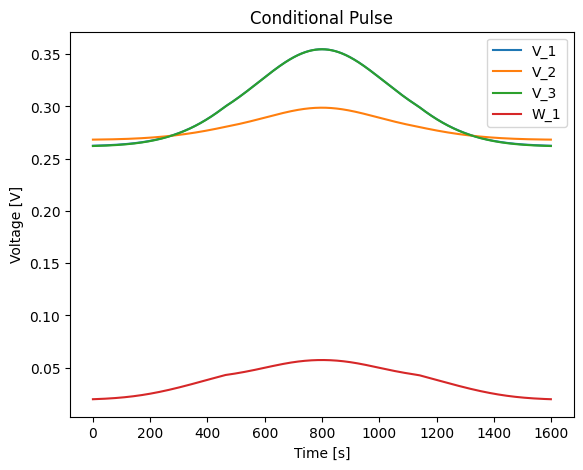

Status: STOPPED, Flags: NONE
Status: STOPPED, Flags: NONE
Trigger events:  0


In [8]:
# Load in pulse data
pulseData = None
with open("conditional_A1_gate_post_readout_example_nodeA.json", encoding="utf-8") as file:
	pulseData = json.load(file)
	file.close()
waveformNames = ["V_1", "V_2", "V_3", "W_1"]

V_1 = pulseData[waveformNames[0]]
V_2 = pulseData[waveformNames[1]]
V_3 = pulseData[waveformNames[2]]
W_1 = pulseData[waveformNames[3]]

# Plot the pulses
fig, ax = plt.subplots(1, 1, figsize=(6.5, 5))
ax.plot(V_1, label=waveformNames[0])
ax.plot(V_2, label=waveformNames[1])
ax.plot(V_3, label=waveformNames[2])
ax.plot(W_1, label=waveformNames[3])
ax.set_xlabel("Time [s]")
ax.set_ylabel("Voltage [V]")
ax.set_title("Resampled Input Pulses")
ax.legend()
ax.set_title("Conditional Pulse")
plt.show()

waveformLength = len(V_1) #Length are in nanoseconds

condSequence = f"""
	set_latch_en	1,4	#Enable listening to triggers on address 1
	wait_sync		4

	#Delete all the previously received triggers
	#Then wait for the QRM pulse to play
	latch_rst		{tof+waveformLengthQRM}
	wait			300		#Makes sure acquisition has been received by the QRM

	set_cond	1, 1, 0, 700			#Enables conditionality dependent upon trigger 1
	play		0, 1, {waveformLength}
	set_cond	0, 1, 0, 700			#Disables the conditionality

	stop
"""

# Set the waveforms to play on the QRM and QCM
waveformsSequencer0 = {
	"V_1" : {"data": (np.array(V_1) / 5).tolist(), "index": 0},
	"W_1" : {"data": (np.array(W_1) / 5).tolist(), "index": 1},
}

# Waveforms on the QCM are divided by 5 because the QCM module has a range from +/2.5V on a 50Ohm load but this goes to +/- 5.0V on a 1MOhm load
# The waveforms are a percentage of this range.
waveformsSequencer1 = {
	"V_2" : {"data": (np.array(V_2) / 5).tolist(), "index": 0},
	"V_3" : {"data": (np.array(V_3) / 5).tolist(), "index": 1},
}

# Upload the JSON files
moduleQCM.sequencer0.sequence({"waveforms": waveformsSequencer0,"weights": {},"acquisitions": {},"program": condSequence})
moduleQCM.sequencer1.sequence({"waveforms": waveformsSequencer1,"weights": {},"acquisitions": {},"program": condSequence})
moduleQCM.arm_sequencer(0)
moduleQCM.arm_sequencer(1)
moduleQRM.arm_sequencer(0)

moduleQCM.start_sequencer()
moduleQRM.start_sequencer()

print(moduleQCM.get_sequencer_state(0))
print(moduleQCM.get_sequencer_state(1))

print("Trigger events: ", cluster.trigger1_monitor_count())